# Perceptron for Binary Classification

## Task 1: Dataset Setup

**Steps:**

1. Import the necessary libraries
    - Use PyTorch (`torch`) for tensor operations
    - Use Scikit-learn's `make_classification` to generate synthetic data
    - Import matplotlib for visualization

In [1]:
# Import libraries

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [3]:
# Generate Synthetic Dataset and convert to PyTorch Tensors

# Generate binary classification dataset

X, y = make_classification(
    n_samples = 200,
    n_features = 2, 
    n_redundant = 0,
    n_informative = 2,
    n_clusters_per_class = 1,
    class_sep = 1, 
    random_state=42
)

# Convert to PyTorch Sensors

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

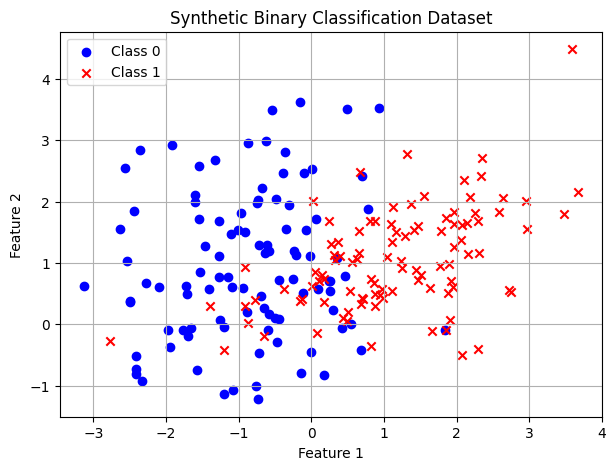

In [5]:
# Visualise dataset with different colors for each class

plt.figure(figsize=(7,5))

# Class 0

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color='blue',
    marker='o',
    label='Class 0'
)

# Class 1

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color = 'red',
    marker ='x',
    label='Class 1'
)

plt.title("Synthetic Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Verify shapes and data types

print(X_tensor.shape)
print(y_tensor.shape)

print(X_tensor.dtype)
print(y_tensor.dtype)

torch.Size([200, 2])
torch.Size([200])
torch.float32
torch.float32


## Task 2: Implementing the Perceptron
**Context:** In industry, understanding how models work "under the hood" is crucial for effective debugging and customization. Building a perceptron from scratch helps cement your understanding of the fundamental building block of neural networks.

**Steps:**

1. Create a Perceptron class
    - Initialize weights and bias as PyTorch tensors
    - Include parameters for input dimension and learning rate

In [7]:
import torch.nn as nn
import torch.nn.functional as F

In [14]:
# Define the perceptron class with appropriate initialization

class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialize weights and bias

        self.weights = torch.randn(input_dim, dtype=torch.float32)
        self.bias = torch.randn(1, dtype=torch.float32)
        self.lr = learning_rate

In [15]:
# Implement forward method for making predictions

def forward(self, x):
    """
    X: tensor of shape [input_dim]
    """
    weighted_sum = torch.dot(self.weights, x) + self.bias
    prediction = torch.sigmoid(weighted_sum)
    return prediction

In [16]:
# Implement weight update based on perceptron learning rule 

def update_weights(self, x, target):
    """
    x: tensor of shape [input_dim]
    target: scalar tensor (0 or 1)
    """
    prediction = self.forward(x)
    error = target - prediction

    # Perceptron learning rule

    self.weights += self.lr * error * x
    self.bias += self.lr * error

In [17]:
# Initialize perceptron

p = Perceptron(input_dim=2, learning_rate=0.1)
print("Initial weights:", p.weights)
print("Initial bias:", p.bias)

Initial weights: tensor([-0.0518,  2.2686])
Initial bias: tensor([-0.1329])


In [20]:
class Perceptron:
    def __init__(self, input_dim, learning_rate=0.01):
        # Initialize weights and bias
        self.weights = torch.randn(input_dim, dtype=torch.float32)
        self.bias = torch.randn(1, dtype=torch.float32)
        self.lr = learning_rate

    def forward(self, x):
        """
        x: tensor of shape [input_dim]
        """
        weighted_sum = torch.dot(self.weights, x) + self.bias
        prediction = torch.sigmoid(weighted_sum)
        return prediction

    def update_weights(self, x, target):
        """
        x: tensor of shape [input_dim]
        target: scalar tensor (0 or 1)
        """
        prediction = self.forward(x)
        error = target - prediction

        # Perceptron learning rule
        self.weights += self.lr * error * x
        self.bias += self.lr * error

In [23]:
# Test Forwards Pass

p = Perceptron(input_dim=2, learning_rate=0.1)

sample_x = torch.tensor([0.5, -1.2], dtype=torch.float32)
pred = p.forward(sample_x)

print("Prediction:", pred.item())

Prediction: 0.8574023842811584


In [24]:
target = torch.tensor(1.0)
print("Before update:", p.weights.clone())

p.update_weights(sample_x, target)

print("After update:", p.weights)

Before update: tensor([-1.4050, -1.2380])
After update: tensor([-1.3979, -1.2551])


## Task 3: Training the Perceptron
**Context:** Training neural networks is an iterative process where the model learns from examples over multiple passes through the dataset (epochs). Monitoring this process helps ensure the model is learning effectively.

**Steps:**

1. Implement the training loop
    - Loop through a specified number of epochs
    - For each epoch, iterate through all training examples
    - Call weight update method for each example
    - Track metrics like accuracy or loss after each epoch

In [25]:
# Implement function to calculate classification accuracy 

def calculate_accuracy(model, X, y):
    correct = 0

    for xi, yi, in zip(X, y):
        pred = model.forward(xi)

        # Convert sigmoid output to binary class

        pred_class = 1 if pred >= 0.5 else 0

        if pred_class == int(yi.item()):
            correct += 1
    
    accuracy = (correct/len(y)) * 100
    return accuracy

In [26]:
# Implement training loop with epoch iterations

def train(model, X, y, epochs=20):
    for epoch in range(epochs):

        # Shuffle data for each epoch

        indices = torch.randperm(len(X))
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Update weights for each example

        for xi, yi in zip(X_shuffled, y_shuffled):
            model.update_weights(xi, yi)

        # Track accuracy 

        acc = calculate_accuracy(model, X, y)

        print(f"Epoch {epoch+1}/{epochs} - Accuracy: {acc: .2f}%")

In [27]:
# Train the model and track progress

p = Perceptron(input_dim=2, learning_rate=0.1)
train(p, X_tensor, y_tensor, epochs = 20)

Epoch 1/20 - Accuracy:  84.00%
Epoch 2/20 - Accuracy:  82.50%
Epoch 3/20 - Accuracy:  84.00%
Epoch 4/20 - Accuracy:  84.00%
Epoch 5/20 - Accuracy:  84.00%
Epoch 6/20 - Accuracy:  85.50%
Epoch 7/20 - Accuracy:  84.00%
Epoch 8/20 - Accuracy:  84.00%
Epoch 9/20 - Accuracy:  83.00%
Epoch 10/20 - Accuracy:  84.00%
Epoch 11/20 - Accuracy:  84.00%
Epoch 12/20 - Accuracy:  85.50%
Epoch 13/20 - Accuracy:  84.00%
Epoch 14/20 - Accuracy:  84.00%
Epoch 15/20 - Accuracy:  83.00%
Epoch 16/20 - Accuracy:  83.00%
Epoch 17/20 - Accuracy:  81.50%
Epoch 18/20 - Accuracy:  83.00%
Epoch 19/20 - Accuracy:  85.00%
Epoch 20/20 - Accuracy:  83.00%


In [28]:
print(p.weights, p.bias)

tensor([ 2.0049, -0.5490]) tensor([0.1142])


## Task 4: Decision Boundary Visualization
**Context:** Visualizing machine learning models helps communicate results to stakeholders and provides insights into how the model makes decisions. For binary classifiers, the decision boundary is particularly informative.

**Steps:**

1. Create a function to plot the decision boundary
    - Generate a mesh grid covering the feature space
    - Make predictions for each point in the grid
    - Use `contourf()` or similar to plot the decision regions
    - Overlay the original data points

In [29]:
# Implement function to visualize decision boundary

def plot_decision_boundary(model, X, y):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Flatten grid and convert to tensor
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

    # Predict for each point
    preds = []
    for point in grid_tensor:
        pred = model.forward(point)
        preds.append(1 if pred >= 0.5 else 0)

    preds = np.array(preds).reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap='coolwarm')

    # Overlay original data
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Class 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class 1')

    plt.title("Perceptron Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

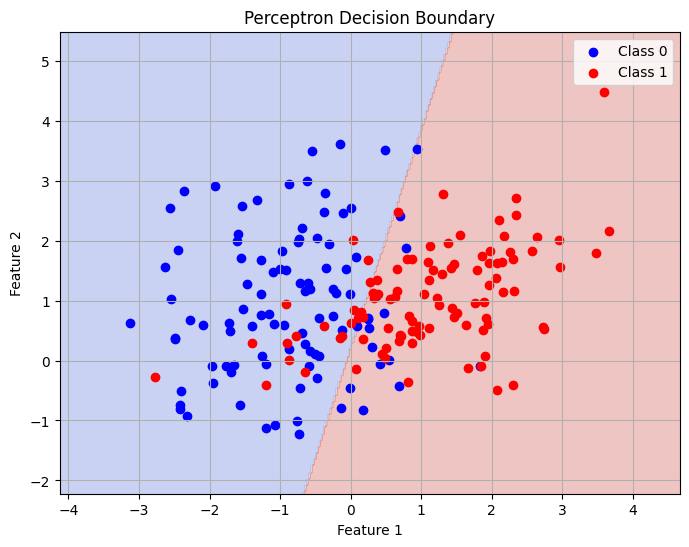

In [30]:
# Call visualization function with trained model
plot_decision_boundary(p, X, y)

In [31]:
# Modify training loop to record weights

def train_with_tracking(model, X, y, epochs=20):
    weight_history = []

    for epoch in range(epochs):
        indices = torch.randperm(len(X))
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for xi, yi in zip(X_shuffled, y_shuffled):
            model.update_weights(xi, yi)

        # Store weights after each epoch
        weight_history.append(model.weights.clone().numpy())

        acc = calculate_accuracy(model, X, y)
        print(f"Epoch {epoch+1}/{epochs} - Accuracy: {acc:.2f}%")

    return np.array(weight_history)

In [32]:
# Function to plot weight evolution

# Implement function to track and visualize weight evolution
def plot_weight_evolution(weight_history):
    plt.figure(figsize=(8, 5))

    plt.plot(weight_history[:, 0], label='Weight 1 (w1)')
    plt.plot(weight_history[:, 1], label='Weight 2 (w2)')

    plt.title("Weight Evolution Over Training")
    plt.xlabel("Epoch")
    plt.ylabel("Weight Value")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 1/20 - Accuracy: 84.50%
Epoch 2/20 - Accuracy: 84.50%
Epoch 3/20 - Accuracy: 85.50%
Epoch 4/20 - Accuracy: 82.00%
Epoch 5/20 - Accuracy: 84.00%
Epoch 6/20 - Accuracy: 84.00%
Epoch 7/20 - Accuracy: 84.50%
Epoch 8/20 - Accuracy: 83.00%
Epoch 9/20 - Accuracy: 81.50%
Epoch 10/20 - Accuracy: 84.00%
Epoch 11/20 - Accuracy: 83.00%
Epoch 12/20 - Accuracy: 83.00%
Epoch 13/20 - Accuracy: 84.00%
Epoch 14/20 - Accuracy: 84.00%
Epoch 15/20 - Accuracy: 84.00%
Epoch 16/20 - Accuracy: 82.00%
Epoch 17/20 - Accuracy: 82.00%
Epoch 18/20 - Accuracy: 83.50%
Epoch 19/20 - Accuracy: 85.50%
Epoch 20/20 - Accuracy: 82.00%


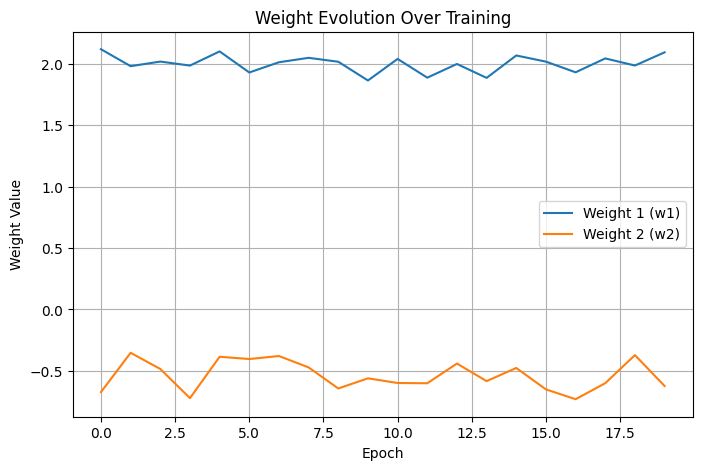

In [33]:
# Train with tracking and visualize

p2 = Perceptron(input_dim=2, learning_rate=0.1)

weight_history = train_with_tracking(p2, X_tensor, y_tensor, epochs=20)

plot_weight_evolution(weight_history)

## Task 5: Experimentation with Learning Rates
**Context:** Learning rate is a critical hyperparameter that affects how quickly and effectively a model learns. In production environments, finding the optimal learning rate can significantly impact model performance.

**Steps:**

1. Modify your training code to experiment with different learning rates
    - Create a list of learning rates to test (e.g., [0.001, 0.01, 0.1, 1.0])
    - Train separate models with each learning rate
    - Track and store training metrics for each

In [34]:
# Training Function That Tracks Accuracy Per Epoch

def train_and_track(model, X, y, epochs=20):
    accuracy_history = []

    for epoch in range(epochs):
        # Shuffle data
        indices = torch.randperm(len(X))
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Update weights
        for xi, yi in zip(X_shuffled, y_shuffled):
            model.update_weights(xi, yi)

        # Track accuracy
        acc = calculate_accuracy(model, X, y)
        accuracy_history.append(acc)

    return accuracy_history

In [35]:
# Implement learning rate experiment

learning_rates = [0.001, 0.01, 0.1, 1.0]
results = {}  # store accuracy curves
models = {}   # store trained models

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = Perceptron(input_dim=2, learning_rate=lr)
    acc_history = train_and_track(model, X_tensor, y_tensor, epochs=20)

    results[lr] = acc_history
    models[lr] = model


Training with learning rate = 0.001

Training with learning rate = 0.01

Training with learning rate = 0.1

Training with learning rate = 1.0


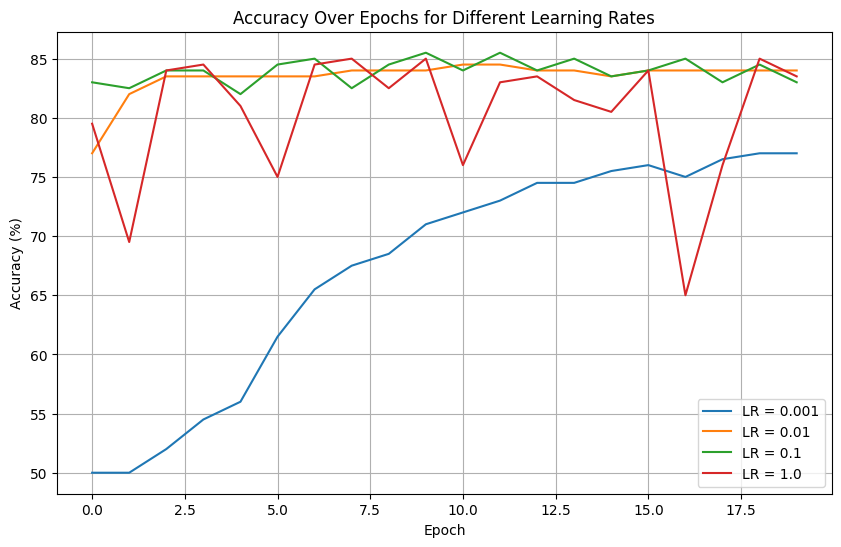

In [36]:
# Create visualization comparing learning rate effects

plt.figure(figsize=(10, 6))

for lr, acc in results.items():
    plt.plot(acc, label=f"LR = {lr}")

plt.title("Accuracy Over Epochs for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

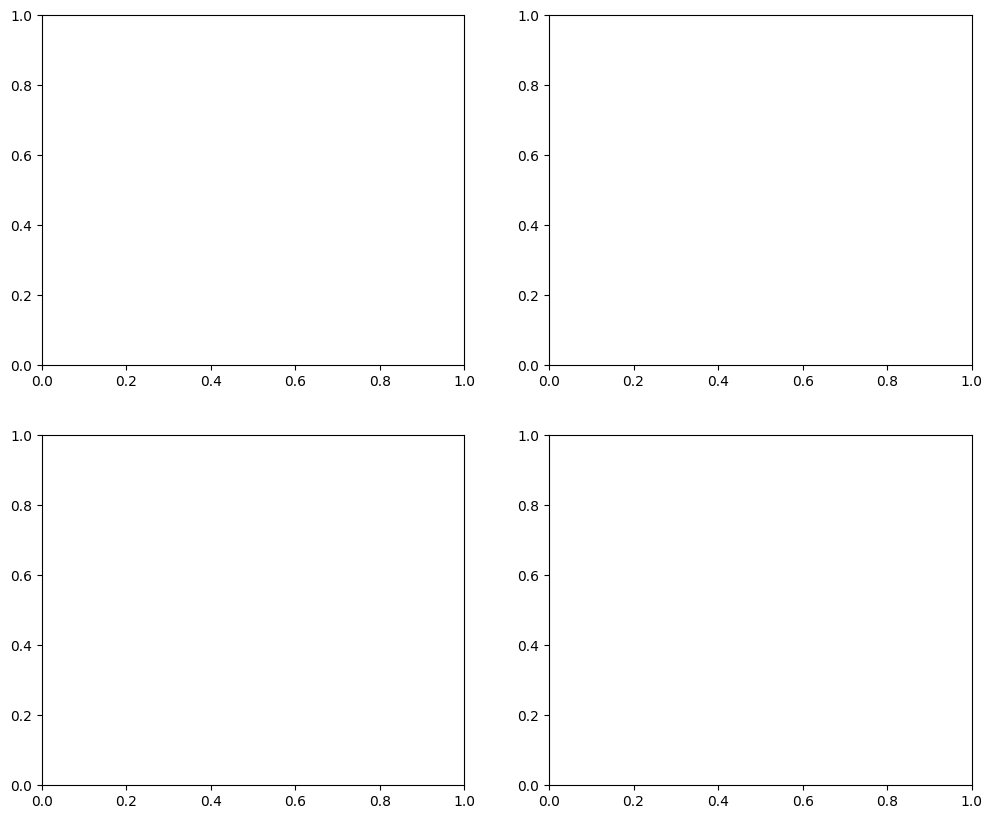

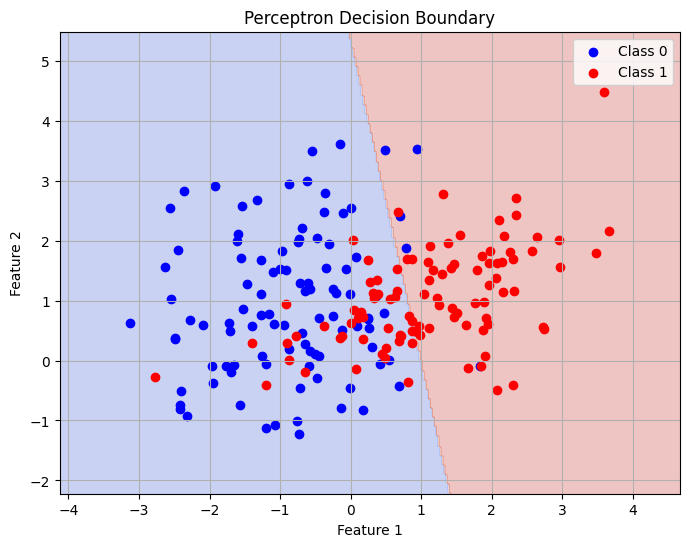

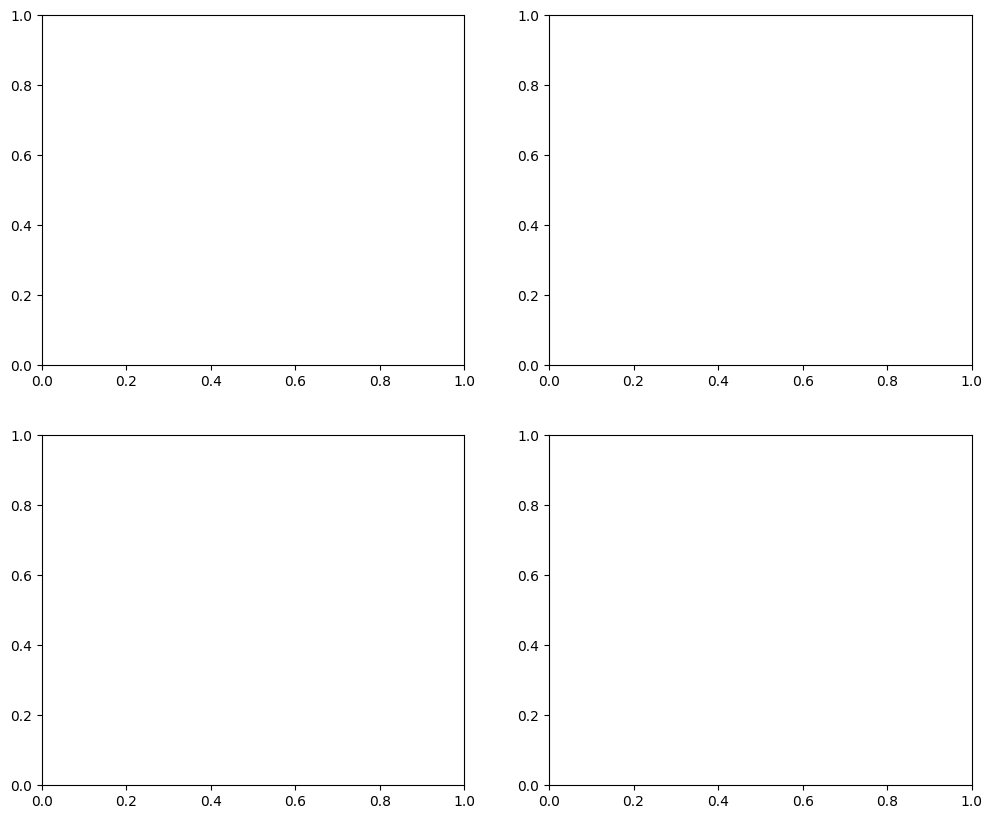

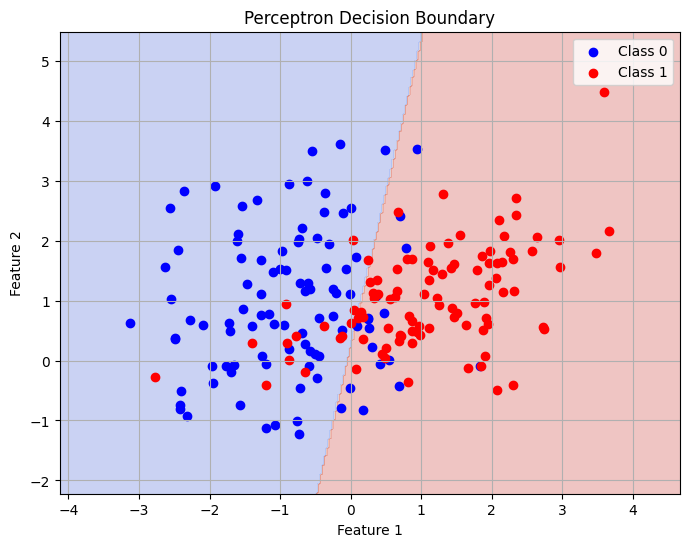

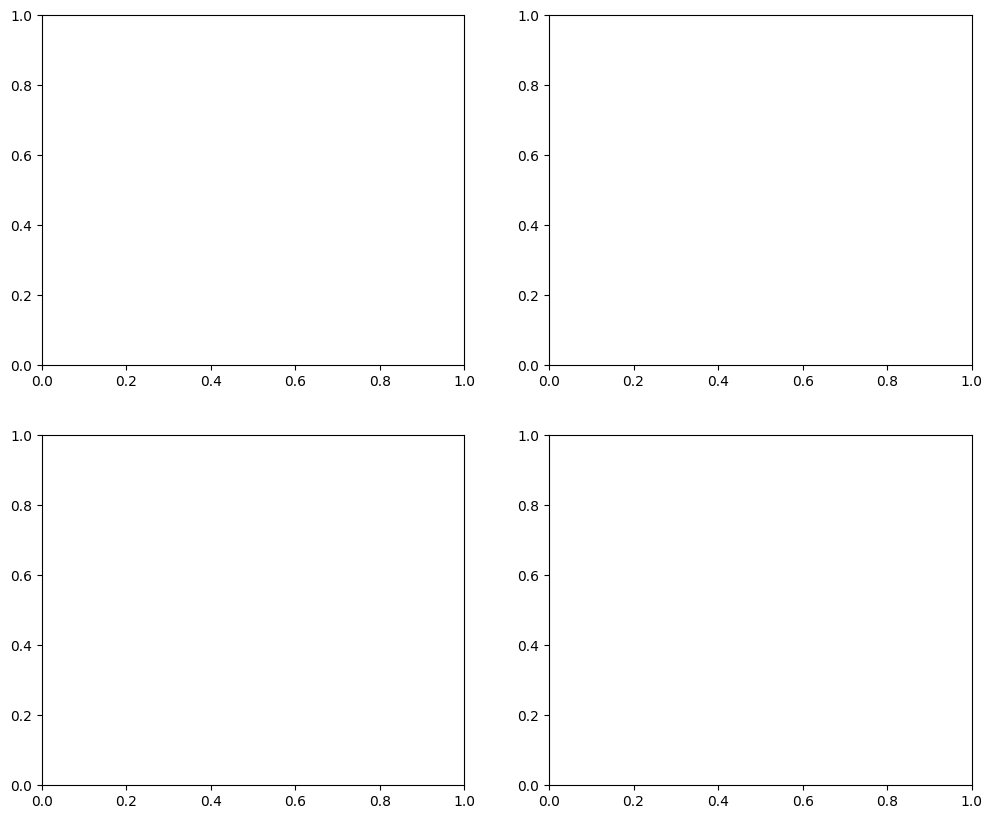

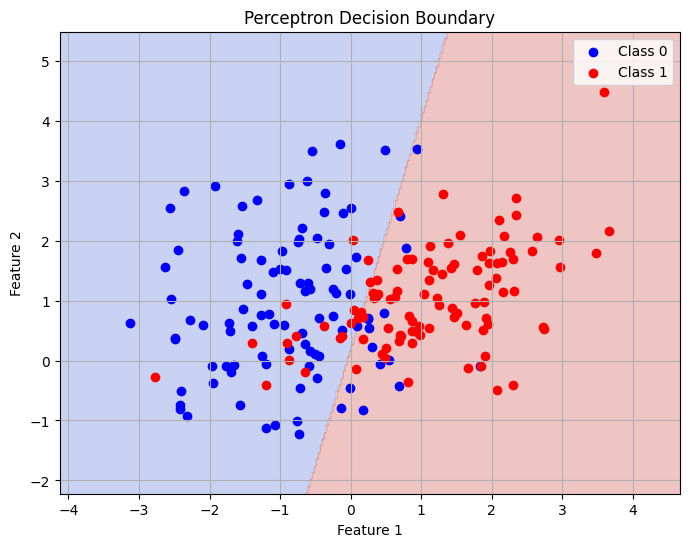

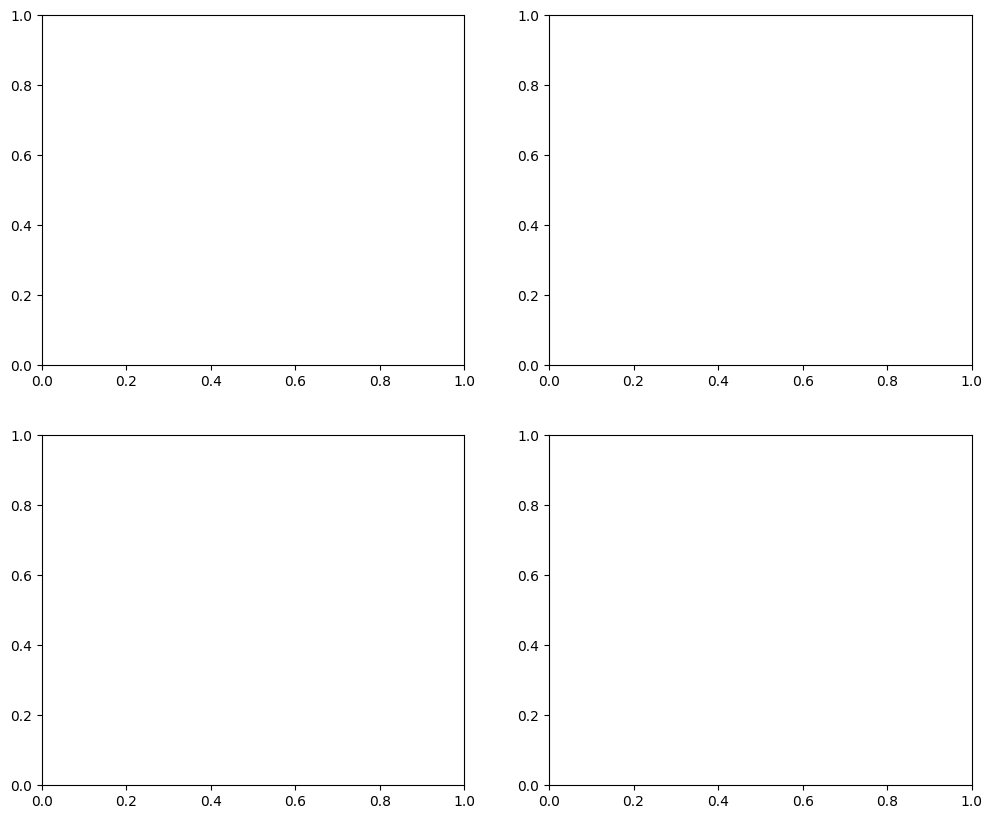

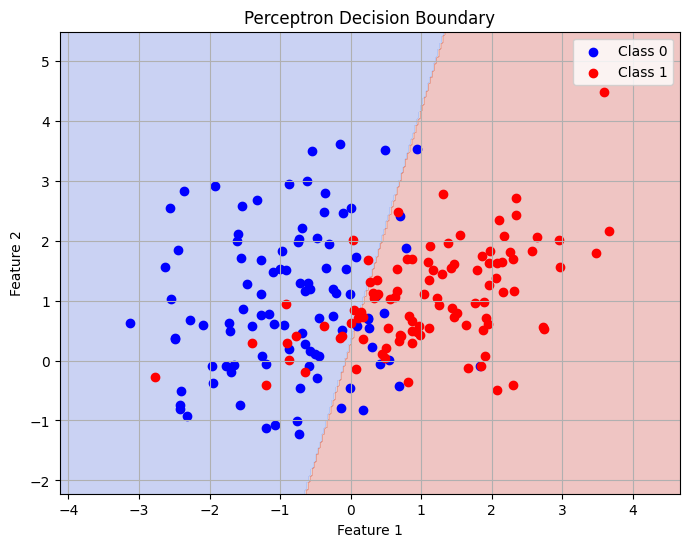

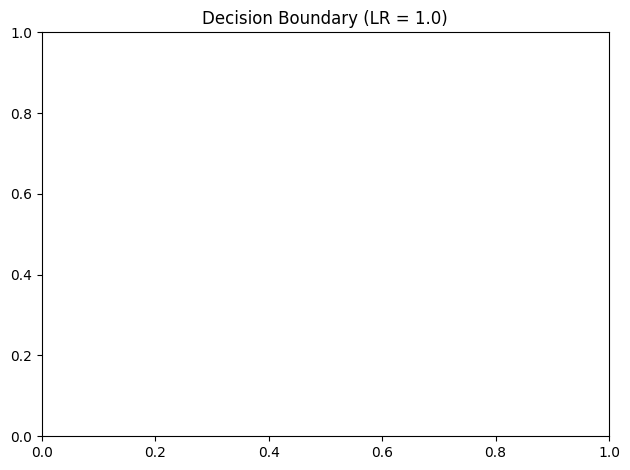

In [37]:
# Visualize Decision Boundaries for Each Learning Rate

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, lr in enumerate(learning_rates):
    plt.sca(axes[idx])
    plot_decision_boundary(models[lr], X, y)
    plt.title(f"Decision Boundary (LR = {lr})")

plt.tight_layout()
plt.show()

In [38]:
# Add code to print analysis of learning rate effects

for lr in learning_rates:
    final_acc = results[lr][-1]
    print(f"Learning Rate {lr}: Final Accuracy = {final_acc:.2f}%")

print("\nAnalysis:")
print("- Very small LR (0.001) should converge slowly and may not reach high accuracy.")
print("- Moderate LR (0.01, 0.1) typically converges well for linearly separable data.")
print("- Very large LR (1.0) may oscillate or fail to converge depending on the dataset.")

Learning Rate 0.001: Final Accuracy = 77.00%
Learning Rate 0.01: Final Accuracy = 84.00%
Learning Rate 0.1: Final Accuracy = 83.00%
Learning Rate 1.0: Final Accuracy = 83.50%

Analysis:
- Very small LR (0.001) should converge slowly and may not reach high accuracy.
- Moderate LR (0.01, 0.1) typically converges well for linearly separable data.
- Very large LR (1.0) may oscillate or fail to converge depending on the dataset.


Percpetron did not converge since the dataset is not linearly separable 